In [1]:
from matplotlib import cm

import scanpy as sc
import os
import numpy as np
import matplotlib.pyplot as plt
import re
from itertools import product
from scipy.stats import spearmanr, pearsonr
import pandas as pd
# helper function for plotting 

def remove_na_and_empty(lst):    
    return [np.array([-0.1]) if np.isnan(el).any() or el.shape == (0,) else el for el in lst]


# SEEDS = [3] #,3,4,5,6,7,8,9] changed  return gene_expression/num_paths to changed  return gene_expression in _PALAVA.py


In [3]:


ERRORS_ =  [f"MS_{i}_EX_0" for i in [ 50]]
ERRORS_ +=  [f"MS_0_EX_{i}" for i in [50]]

# SEED 0 max is 1
# SEED 10 max is 2.5
SEEDS = [10,11,12,13,14]
PERCENT_ACT_SHUFFLE = [100, 26, 10, 5, 2,0]

prefix = 'intermediate_results/'


linear_palava_results = [f'{prefix}linear_palava_results_sim_anndata_linear_model_5000_cells_2000_genes_4_factors_{seed}_seed_{percent_act_shuffle}_percent_act_shuffle_gene_sets_formatted_{error}.npy' for seed, error,percent_act_shuffle in product(SEEDS, ERRORS_,PERCENT_ACT_SHUFFLE)]

palava_results = [f'{prefix}palava_results_sim_anndata_linear_model_5000_cells_2000_genes_4_factors_{seed}_seed_{percent_act_shuffle}_percent_act_shuffle_gene_sets_formatted_{error}.npy' for seed, error,percent_act_shuffle in product(SEEDS, ERRORS_,PERCENT_ACT_SHUFFLE)]

spectra_results = [f'{prefix}spectra_results_sim_anndata_linear_model_5000_cells_2000_genes_4_factors_{seed}_seed_{percent_act_shuffle}_percent_act_shuffle_gene_sets_formatted_{error}.npy' for seed, error,percent_act_shuffle in product(SEEDS, ERRORS_,PERCENT_ACT_SHUFFLE)]
slalom_results = [f'{prefix}slalom_results_sim_anndata_linear_model_5000_cells_2000_genes_4_factors_{seed}_seed_{percent_act_shuffle}_percent_act_shuffle_gene_sets_formatted_{error}.npy' for seed, error,percent_act_shuffle in product(SEEDS, ERRORS_,PERCENT_ACT_SHUFFLE)]


In [4]:
result_directory_lst = palava_results \
                        +linear_palava_results\
                        +spectra_results\
                        +slalom_results


In [5]:
#result_directory_lst = [directory for directory in result_directory_lst if os.path.exists(directory)]


In [6]:

methods = ['palava','linear_palava', 'spectra', 'slalom'] # 'palava',
results_dict ={m:{} for m in methods}

data_directory_lst = list(set([data_directory.split('results_')[1].replace('.npy','') for data_directory in result_directory_lst]))

for method in methods:
    results_dict[method]['result_directorys'] = []
    #results_dict[method]['result_lst'] = {}

    for data_directory in  result_directory_lst:
        data_directory_method = re.search(r'intermediate_results/(.*?)_res', data_directory).group(1) if re.search(r'intermediate_results/(.*?)_res', data_directory) else None
        if  data_directory_method == method:
            
            results_dict[method]['result_directorys'] += [data_directory.split('results_')[1].replace('.npy','')]
            results_dict[method][data_directory.split('results_')[1].replace('.npy','')] = np.load(data_directory, allow_pickle=True)[()]
            # too much meme in load the slopes 
            if 'spline_slopes' in results_dict[method][data_directory.split('results_')[1].replace('.npy','')].keys():
                del results_dict[method][data_directory.split('results_')[1].replace('.npy','')]['spline_slopes']


In [7]:

# Determine num cells, genes, factors from file name
pattern = r'(\d+)'
matches = re.findall(pattern, data_directory_lst[0])
num_cells, num_genes, num_facs_ann = map(int, matches[:3])
print(f'num_cells: {num_cells}, num_genes: {num_genes}, Factors: {num_facs_ann}')


num_cells: 5000, num_genes: 2000, Factors: 4


In [8]:
pattern = r'FN_(\d+)_FP_(\d+)'

# Initialize lists to store extracted values
fn_values = []
fp_values = []

# Iterate over the filenames and extract FN and FP values
for filename in result_directory_lst:
    match = re.search(pattern, filename)
    if match:
        fn_values.append(int(match.group(1)))
        fp_values.append(int(match.group(2)))
fn_values = list(set(fn_values))
fp_values = list(set(fp_values))



In [9]:
results_dict['adata']= {}
for data_directory in data_directory_lst:
    adata_data_directory = 'data/' + data_directory + '.h5ad'
    results_dict['adata'][data_directory] = sc.read(adata_data_directory)
   # print(results_dict['adata'][data_directory].uns['Ground truth gene sets'].sum(axis =0))



In [10]:


# for method in ['palava']:
#     for results in results_dict[method]['result_directorys']:
#         results_dict[method][results]['factor_loadings'] = results_dict[method][results]['factor_loadings_0.85q']
            


In [11]:


for method in methods:
    for results in results_dict[method]['result_directorys']:
            
            a_methods_factor_loadings = np.abs(results_dict[method][results]['factor_loadings'][:4,:])
            if method in ['slalom','default_slalom'] :
                        a_methods_factor_loadings = np.abs(results_dict[method][results]['posterior'][:4,:])

            gt_tols = 1-results_dict['adata'][results].uns['Ground truth gene sets'].sum(axis =0)/num_genes

            gt_tols_as_quantiles = np.diagonal(np.quantile(a_methods_factor_loadings, q = gt_tols[:, None], axis =1), axis1=1, axis2=2)

            top_per_a_methods_factor_loadings = a_methods_factor_loadings >= gt_tols_as_quantiles
        
            top_per_a_methods_factor_loadings_and_GT_gene = (results_dict['adata'][results].uns['Ground truth gene sets'].T==1) & top_per_a_methods_factor_loadings

            results_dict[method][results]['fraction_of_GT_in_top_genes'] =np.sum(top_per_a_methods_factor_loadings_and_GT_gene, axis =1)/np.sum(results_dict['adata'][results].uns['Ground truth gene sets'].T, axis =1)




for method in methods:
    for results in results_dict[method]['result_directorys']:
        
            a_methods_factor_loadings = np.abs(results_dict[method][results]['factor_loadings'][:4,:])
        
            if method in ['slalom','default_slalom'] :
                        a_methods_factor_loadings = np.abs(results_dict[method][results]['posterior'][:4,:])


            gt_tols = 1-results_dict['adata'][results].uns['Ground truth gene sets'].sum(axis =0)/num_genes

            gt_tols_as_quantiles = np.diagonal(np.quantile(a_methods_factor_loadings, q = gt_tols, axis =1).squeeze(), axis1=0, axis2=1)[:,None]

            top_per_a_methods_factor_loadings = a_methods_factor_loadings >= gt_tols_as_quantiles
            
        
            
            
            top_per_a_methods_factor_loadings_and_FN_gene = results_dict['adata'][results].uns['FN_genes'].T & top_per_a_methods_factor_loadings

            results_dict[method][results]['fraction_of_FN_recovered'] =np.sum(top_per_a_methods_factor_loadings_and_FN_gene, axis =1)/np.sum(results_dict['adata'][results].uns['FN_genes'].T, axis =1)
            results_dict[method][results]['num_of_FN_recovered'] =np.sum(top_per_a_methods_factor_loadings_and_FN_gene, axis =1)

            bottom_per_a_methods_factor_loadings = a_methods_factor_loadings >= gt_tols_as_quantiles
            bottom_per_a_methods_factor_loadings_and_FN_gene = results_dict['adata'][results].uns['FP_genes'].T & bottom_per_a_methods_factor_loadings
            results_dict[method][results]['fraction_of_FP_removed'] = np.sum(bottom_per_a_methods_factor_loadings_and_FN_gene, axis =1)/np.sum(results_dict['adata'][results].uns['Ground truth gene sets'].T, axis =1)
       
            results_dict[method][results]['num_of_FP_not_removed'] = np.sum(bottom_per_a_methods_factor_loadings_and_FN_gene, axis =1) 

/tmp/ipykernel_239623/618302842.py:41: RuntimeWarning: invalid value encountered in divide
  results_dict[method][results]['fraction_of_FN_recovered'] =np.sum(top_per_a_methods_factor_loadings_and_FN_gene, axis =1)/np.sum(results_dict['adata'][results].uns['FN_genes'].T, axis =1)


In [12]:

def pairwise_spearman_correlation(matrix1, matrix2):
    correlations = np.zeros((matrix1.shape[1], matrix2.shape[1]))
    for i in range(matrix1.shape[1]):
        for j in range(matrix2.shape[1]):
            correlation, _ = spearmanr(matrix1[:, i], matrix2[:, j])
            correlations[i, j] = correlation
    return correlations


for method in methods:
    for results in results_dict[method]['result_directorys']:
        if method in ['no_anno_palava','no_anno_linear_palava_no_bias']:
            latent = results_dict[method][results]['latent_representation']
            gt = results_dict['adata'][results].obs[['steps_1', 'steps_2', 'steps_3', 'steps_4']].values
            results_dict[method][results]['latent_respresentation_correlation_with_gt'] = np.max(np.abs(pairwise_spearman_correlation(latent,gt)), axis =0)
            continue 
        gt_latent_representation = results_dict['adata'][results].obs[['steps_1', 'steps_2', 'steps_3', 'steps_4']].values
        a_methods_latent_representation = results_dict[method][results]['latent_representation']
     
        correlations = [spearmanr(gt_latent_representation[:, i], a_methods_latent_representation[:, i]).correlation for i in range(4)]
        results_dict[method][results]['latent_respresentation_correlation_with_gt'] = np.abs(correlations)
            

In [13]:


fraction_of_FP_removed = [np.array([]) for _ in methods]
fraction_of_FN_recovered = [np.array([]) for _ in methods]
fraction_of_GT_in_top_genes = [np.array([]) for _ in methods]
latent_corr_with_gt = [np.array([]) for _ in methods]
for method_ind in range(len(methods)):
    for results in results_dict[methods[method_ind]]['result_directorys']:
            fraction_of_FP_removed[method_ind] = np.append(results_dict[methods[method_ind]][results]['fraction_of_FP_removed'], fraction_of_FP_removed[method_ind] )
            fraction_of_FN_recovered[method_ind] = np.append(results_dict[methods[method_ind]][results]['fraction_of_FN_recovered'], fraction_of_FN_recovered[method_ind] )
            fraction_of_GT_in_top_genes[method_ind] = np.append(results_dict[methods[method_ind]][results]['fraction_of_GT_in_top_genes'], fraction_of_GT_in_top_genes[method_ind] )
            latent_corr_with_gt[method_ind] = np.append(results_dict[methods[method_ind]][results]['latent_respresentation_correlation_with_gt'], latent_corr_with_gt[method_ind] )

fraction_of_FP_removed = remove_na_and_empty(fraction_of_FP_removed)
fraction_of_FN_recovered = remove_na_and_empty(fraction_of_FN_recovered)
fraction_of_GT_in_top_genes = remove_na_and_empty(fraction_of_GT_in_top_genes)
latent_corr_with_gt = remove_na_and_empty(latent_corr_with_gt)



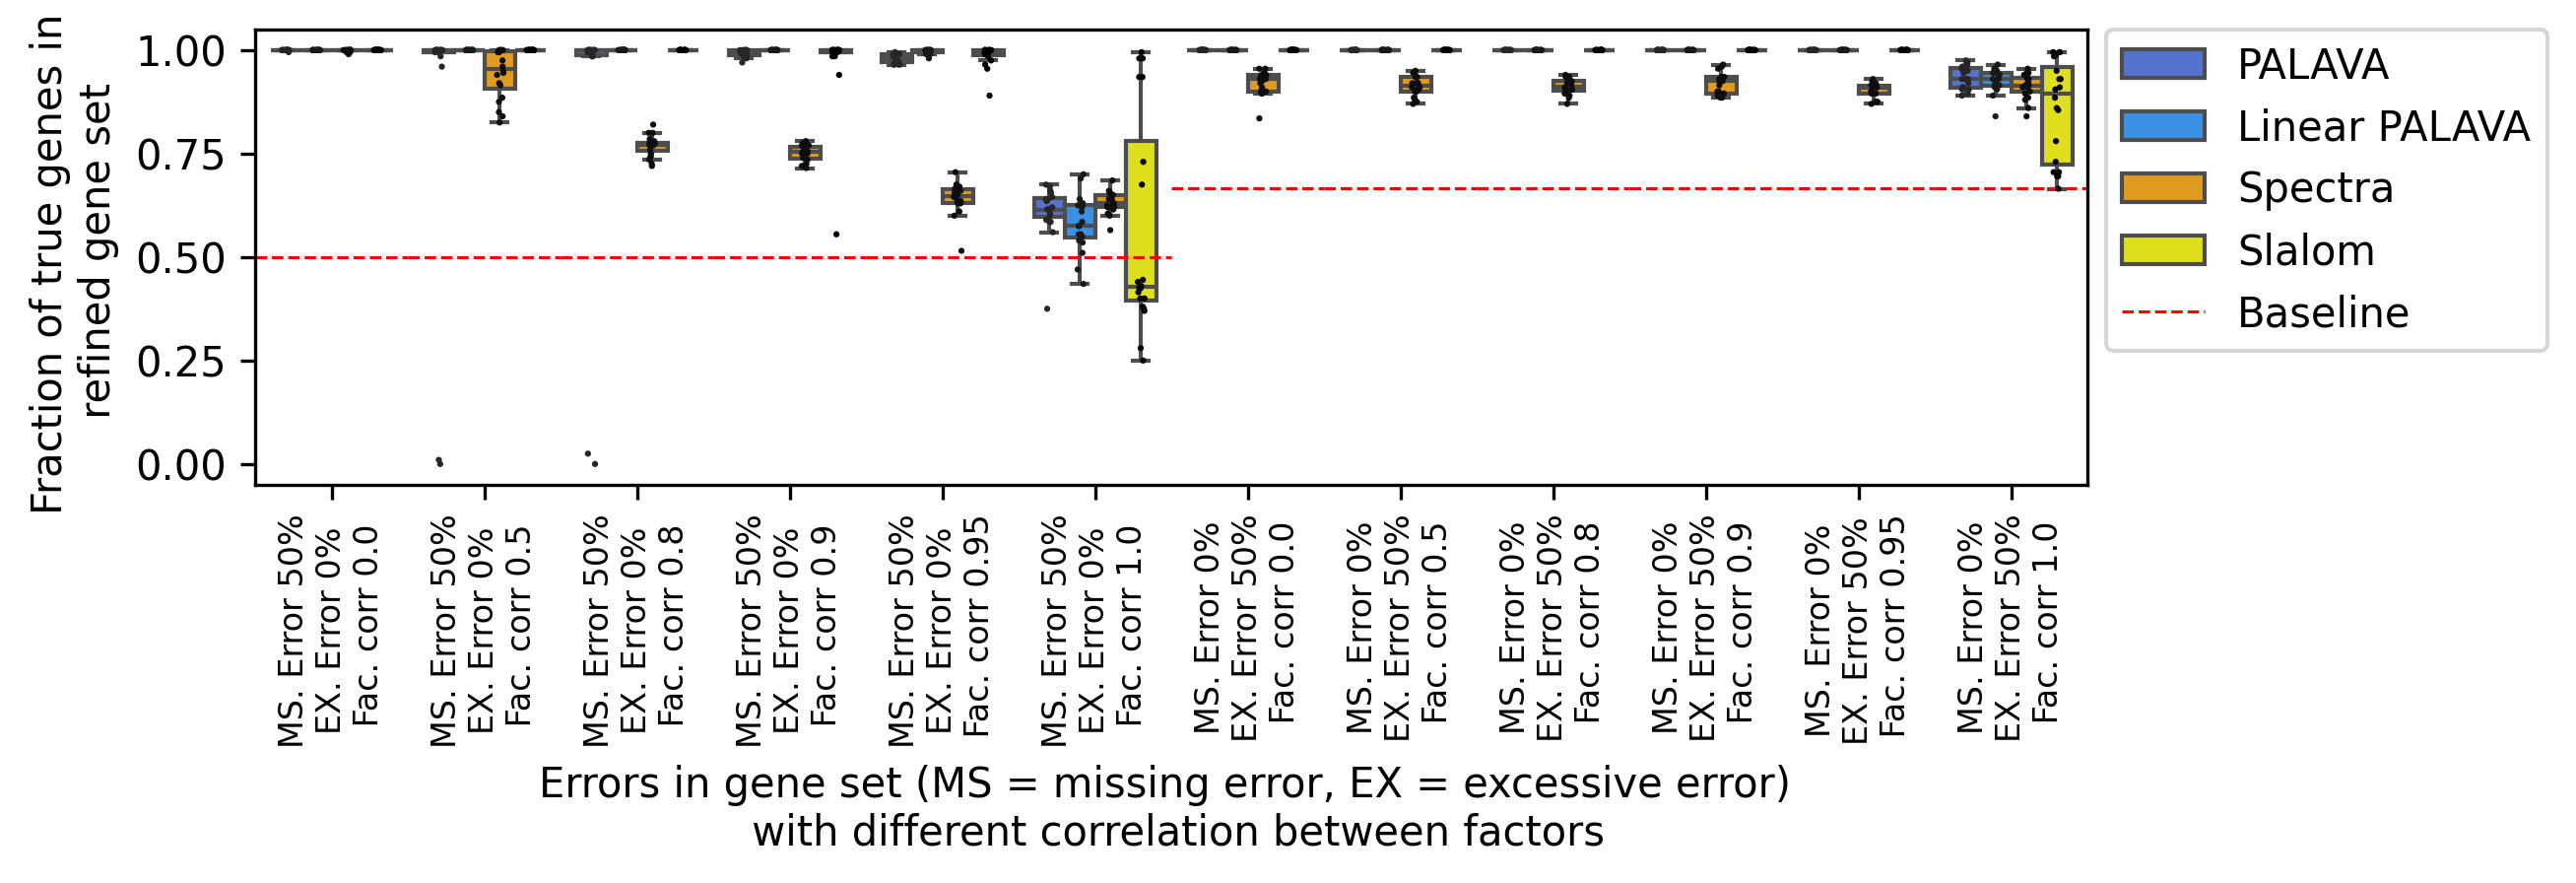

In [14]:
from matplotlib.patches import PathPatch



FAC_CORR = [0.0,0.5,0.8,0.9, 0.95, 1.0]
ERRORS_plot = [f'_{per_act_shuff}_percent_act_shuffle_gene_sets_formatted_{er}' for er in  ERRORS_ for per_act_shuff in  PERCENT_ACT_SHUFFLE]

ERRORS_plot_labels =[]

for er in ERRORS_plot:
            pattern = r'(\d+)_percent_act_shuffle_gene_sets_formatted_MS_(\d+)_EX_(\d+)'
            # Use re.findall to extract values
            per_act_shuffle, fn_value, fp_value = re.findall(pattern, er)[0]

            corr =  FAC_CORR[PERCENT_ACT_SHUFFLE.index(int(per_act_shuffle))]   
            ERRORS_plot_labels.append(f'MS. Error {fn_value}%\nEX. Error {fp_value}%\n Fac. corr {corr}')
        

plot_dict = {method:[] for method in methods}
plot_dict['errors'] = []

for error in ERRORS_plot:
        for method in methods:
            for results in results_dict[method]['result_directorys']:
                   if error in  results:
                        if  method==methods[0]:
                            plot_dict['errors'] += [ERRORS_plot_labels[ERRORS_plot.index(error)]] *num_facs_ann
                            
        
                        top_gene_scores = results_dict[method][results]['fraction_of_GT_in_top_genes'].tolist()
                        plot_dict[method] += top_gene_scores



#for method in ['no_anno_palava','no_anno_linear_palava']:
#    plot_dict[method] += [None] *(len(plot_dict['palava'])- len(plot_dict[method]))



# for method in ['no_anno_palava','no_anno_linear_palava_no_bias']:
#     plot_dict[method] += [None] *(len(plot_dict['palava'])- len(plot_dict[method]))


df = pd.DataFrame(plot_dict)

methods_to_plot = ['palava','linear_palava','spectra', 'slalom']  # 'palava',


df = pd.melt(df,id_vars=['errors'],value_vars=methods_to_plot,
             var_name='methods', value_name='Fraction of genes recovered')

# ['palava', 'linear_palava_no_bias', 'spectra', 'default_slalom']

new_method_names = ['PALAVA', 'Linear PALAVA', 'Spectra', 'Slalom' ] # 'PALAVA',
replacement_dict = { methods_to_plot[i]:new_method_names[i] for i in range(len(methods_to_plot))}
    
df= df.replace(replacement_dict)



colors_lst = ['royalblue','dodgerblue','orange', 'yellow']#, 'skyblue', 'darkblue', 'deepskyblue', 'orange', 'green']

custom_palette = {new_method_names[i]:colors_lst[i] for i in range(len(methods_to_plot))
  
}


import seaborn as sns
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8, 2), dpi =300) #for a bigger image
ax = sns.boxplot(
    x="errors", y='Fraction of genes recovered', hue='methods', data=df, palette=custom_palette, showfliers=False
)

baseline_dict = {}
baseline_dict['errors']= list(set(plot_dict['errors']))
baseline_dict['baseline'] = []


# baseline value data to plot
for er in baseline_dict['errors']:
    pattern = r'(?:MS\. Error|EX\. Error) (\d+)'#r'MS. Error (\d+)_EX. Error (\d+)'
        # Use re.findall to extract values
    ms_value, ex_value = re.findall(pattern, er)
    m = int(ms_value)/100
    s = int(ex_value)/100
    baseline_dict['baseline'] +=  [(1-m)/(1+s)]


# Add horizontal lines for baseline values
for error, baseline_value in zip(baseline_dict['errors'], baseline_dict['baseline']):
    x_pos = df[df['errors'] == error]['errors'].iloc[0]
    x_pos = ERRORS_plot_labels.index(x_pos)
    # Draw horizontal line
    width = 0.5
    plt.hlines(y=baseline_value, xmin=x_pos - width, xmax=x_pos + width, color='r', linestyle='--', label=f"Baseline", linewidth=0.75)




# Add the scatter plot 
sns.stripplot(
    x="errors", y='Fraction of genes recovered', hue='methods', data=df, size=1.5, jitter=True, palette="dark:black", dodge=True,legend = 'full'
)

plt.xlabel("Errors in gene set (MS = missing error, EX = excessive error) \n with different correlation between factors", fontsize =10)
plt.ylabel("Fraction of true genes in \n refined gene set", fontsize =10)
plt.xticks(rotation=90, fontsize =8)  # Rotate x labels to prevent overlapping
#plt.ylim([ 0.45, 1])
handles, labels = ax.get_legend_handles_labels()

l = plt.legend(handles[0:len(methods_to_plot)+1], labels[0:len(methods_to_plot)+1], bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0.)

#plt.savefig('figures/method_comparison_linear_correlation_between_factors_frac_of_refined_gene_set.png', dpi = 150, bbox_inches="tight")

plt.show()





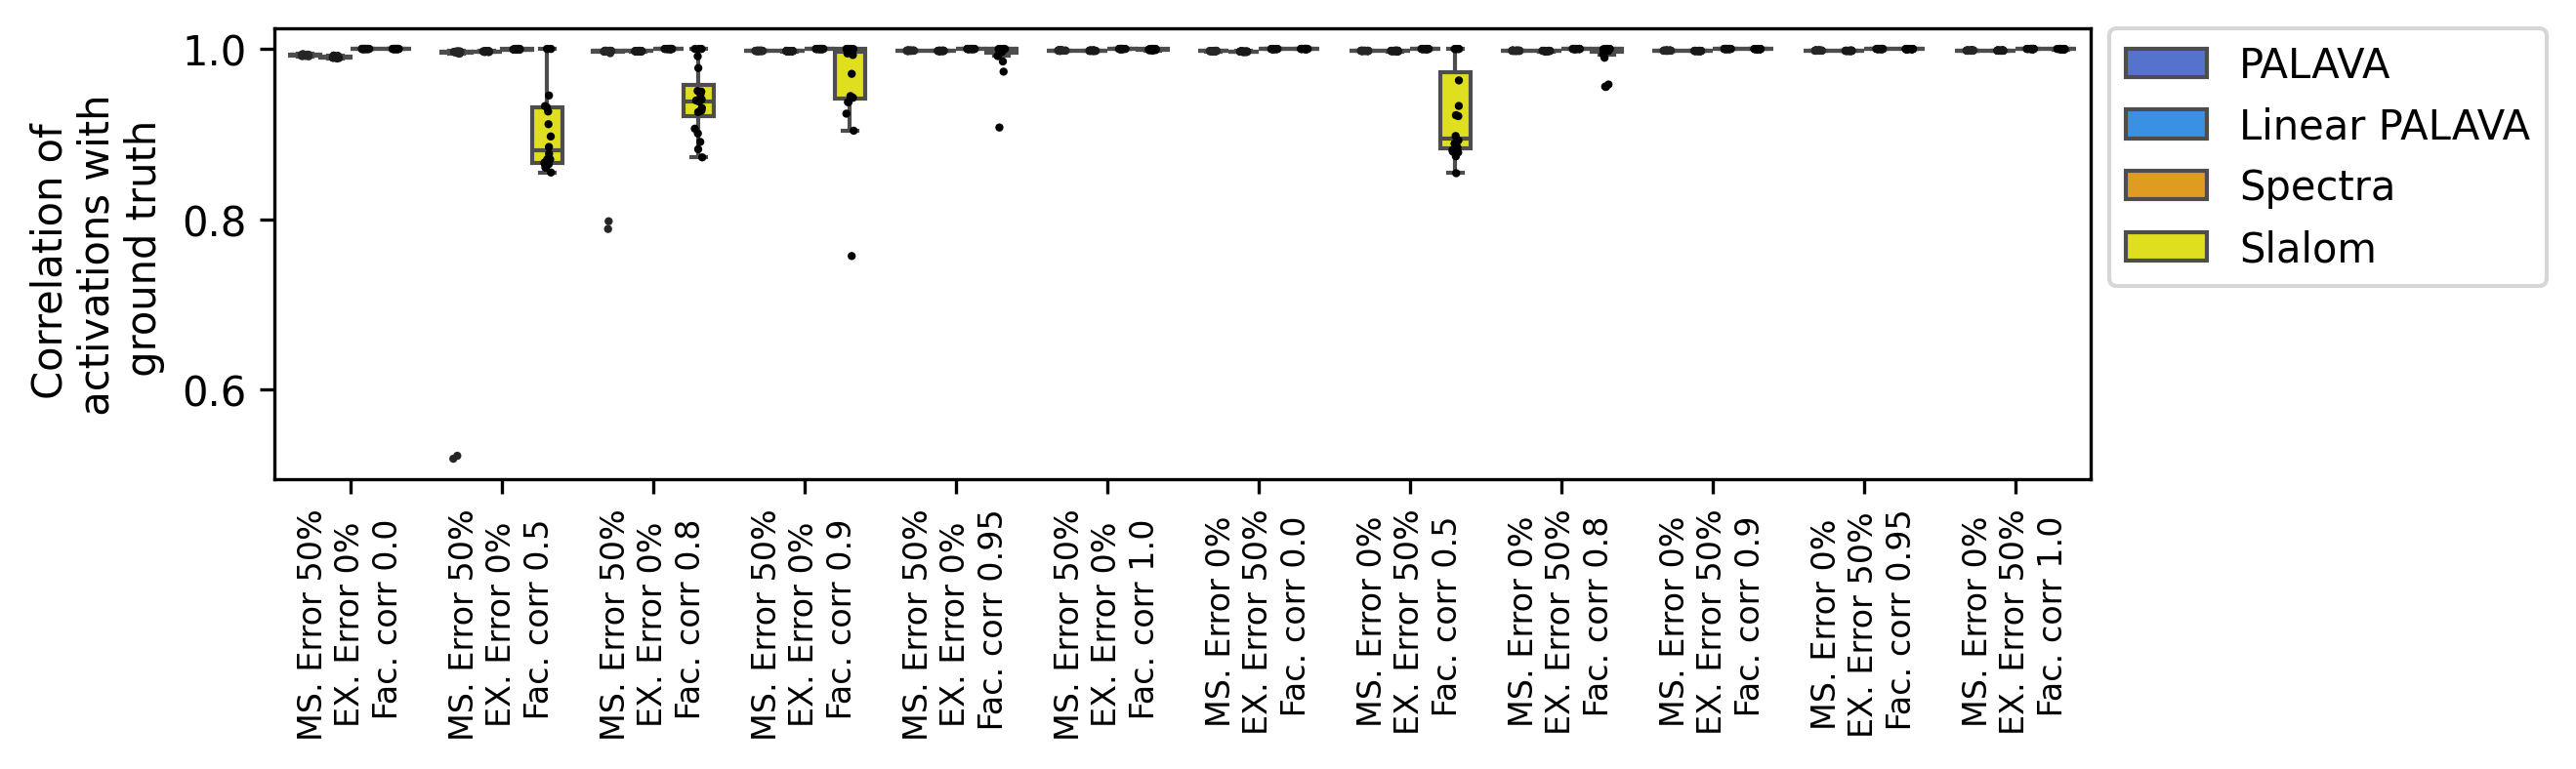

In [15]:

ERRORS_plot = [f'_{per_act_shuff}_percent_act_shuffle_gene_sets_formatted_{er}' for er in  ERRORS_ for per_act_shuff in  PERCENT_ACT_SHUFFLE]

ERRORS_plot_labels =[]

for er in ERRORS_plot:
            pattern = r'(\d+)_percent_act_shuffle_gene_sets_formatted_MS_(\d+)_EX_(\d+)'
            # Use re.findall to extract values
            per_act_shuffle, fn_value, fp_value = re.findall(pattern, er)[0]

            corr =  FAC_CORR[PERCENT_ACT_SHUFFLE.index(int(per_act_shuffle))]   
            ERRORS_plot_labels.append(f'MS. Error {fn_value}%\nEX. Error {fp_value}%\n Fac. corr {corr}')
        

plot_dict = {method:[] for method in methods}
plot_dict['errors'] = []

for error in ERRORS_plot:
        for method in methods:
            for results in results_dict[method]['result_directorys']:
                   if error in  results:
                        if  method==methods[0]:
                            plot_dict['errors'] += [ERRORS_plot_labels[ERRORS_plot.index(error)]] *num_facs_ann
                            
        
                        top_gene_scores = results_dict[method][results]['latent_respresentation_correlation_with_gt'].tolist()
        
                        plot_dict[method] += top_gene_scores





df = pd.DataFrame(plot_dict)



methods_to_plot = ['palava','linear_palava','spectra', 'slalom']  # 'palava',
df = pd.melt(df,id_vars=['errors'],value_vars=methods_to_plot,
             var_name='Errors', value_name='Correlation of activations with ground truth')




new_method_names = ['PALAVA', 'Linear PALAVA', 'Spectra', 'Slalom' ] # 'PALAVA',
replacement_dict = { methods_to_plot[i]:new_method_names[i] for i in range(len(methods_to_plot))}
    
df= df.replace(replacement_dict)

colors_lst = ['royalblue','dodgerblue','orange', 'yellow']#, 'skyblue', 'darkblue', 'deepskyblue', 'orange', 'green']

custom_palette = {new_method_names[i]:colors_lst[i] for i in range(len(new_method_names))
  
}

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 2), dpi =300) #for a bigger image
ax = sns.boxplot(
    x="errors", y='Correlation of activations with ground truth', hue='Errors', data=df, palette=custom_palette, showfliers=False
)

# Add the scatter plot with updated palette
sns.stripplot(
    x="errors", y='Correlation of activations with ground truth', hue='Errors', data=df, size=2, jitter=True, palette="dark:black", dodge=True,legend = 'full'
)


# Customize the plot
plt.xlabel("")
plt.ylabel("Correlation of \n activations with \n ground truth")
plt.xticks(rotation=90, fontsize =8)  # Rotate x labels to prevent overlapping

handles, labels = ax.get_legend_handles_labels()

# When creating the legend, only use the first two elements
# to effectively remove the last two.
l = plt.legend(handles[0:len(methods_to_plot)], labels[0:len(methods_to_plot)], bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0.)
#plt.savefig('figures/method_comparison_linear_correlation_between_factors_corr_of_ground_truth_factors.png', dpi = 150, bbox_inches="tight")

plt.show()



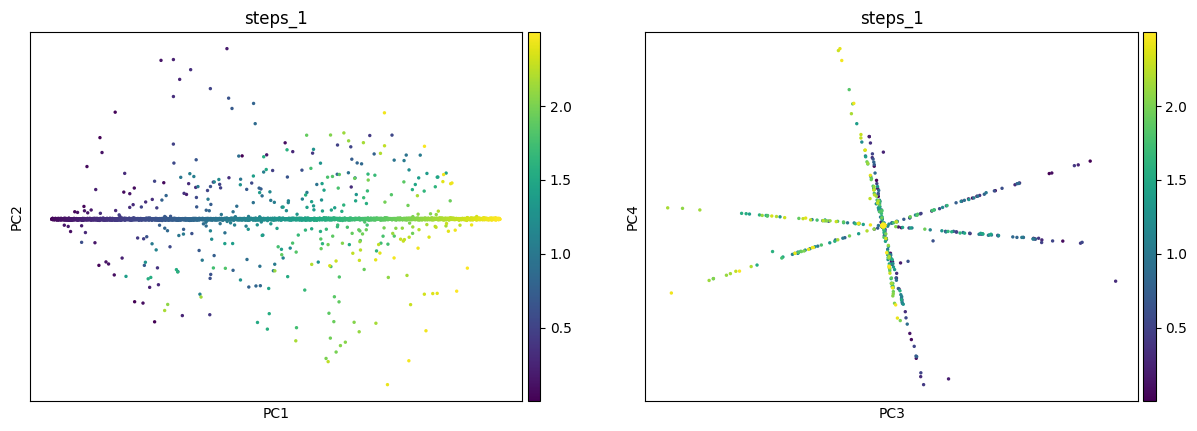

In [19]:
adata =sc.read('data/sim_anndata_linear_model_5000_cells_2000_genes_4_factors_10_seed_2_percent_act_shuffle_gene_sets_formatted_MS_50_EX_0.h5ad')
sc.tl.pca(adata, layer = 'logcounts')
sc.pl.pca(adata, color ='steps_1', components= ["1,2", "3,4"])

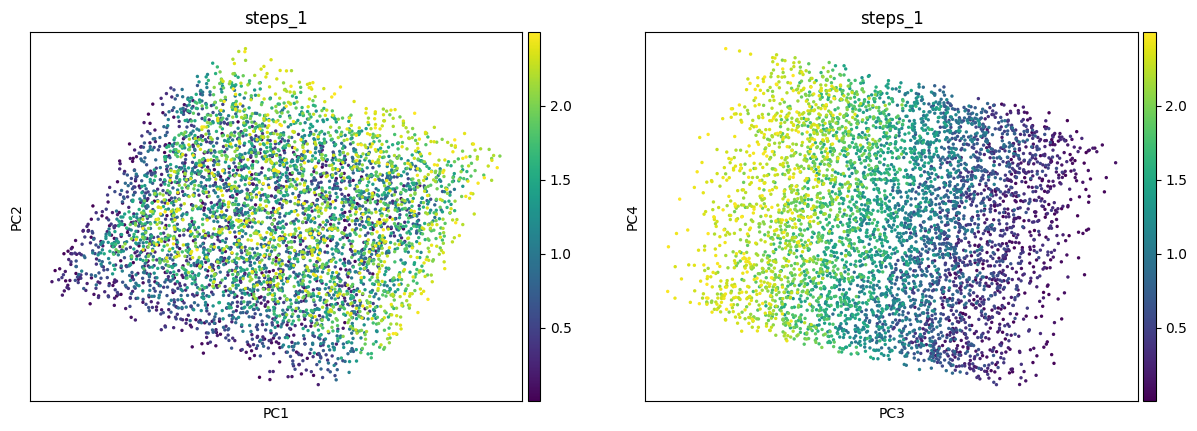

In [20]:
adata =sc.read('data/sim_anndata_linear_model_5000_cells_2000_genes_4_factors_10_seed_100_percent_act_shuffle_gene_sets_formatted_MS_50_EX_0.h5ad')
sc.tl.pca(adata, layer = 'logcounts')
sc.pl.pca(adata, color ='steps_1', components= ["1,2", "3,4"])